**Goal:** Which team statistics most strongly predict winning in the NBA, and how has that changed from 2010–2024?

In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to SQLite database (creates file if it doesn’t exist)
conn = sqlite3.connect("my_project.db")

# Load CSVs into pandas
team_stats_per_game = "C:/Users/chipm/OneDrive/Documents/Team Stats Per Game.csv"
team_summaries = "C:/Users/chipm/OneDrive/Documents/Team Summaries.csv"
team_totals =  "C:/Users/chipm/OneDrive/Documents/Team Totals.csv"
t_stat = pd.read_csv(team_stats_per_game)
t_summ = pd.read_csv(team_summaries)
t_tot = pd.read_csv(team_totals)

# Write DataFrames to SQLite database
t_stat.to_sql("team_stats_per_game", conn, if_exists="replace", index=False)
t_summ.to_sql("team_summaries", conn, if_exists="replace", index=False)
t_tot.to_sql("team_totals", conn, if_exists="replace", index=False)


Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'age', 'w', 'l',
       'pw', 'pl', 'mov', 'sos', 'srs', 'o_rtg', 'd_rtg', 'n_rtg', 'pace',
       'f_tr', 'x3p_ar', 'ts_percent', 'e_fg_percent', 'tov_percent',
       'orb_percent', 'ft_fga', 'opp_e_fg_percent', 'opp_tov_percent',
       'drb_percent', 'opp_ft_fga', 'arena', 'attend', 'attend_g'],
      dtype='object')


**Data Cleaning**


In [3]:


# Join tables to have: 3P attempts, w%, pace, offensive rating, defensive rating, turnovers, wins
def run_query(sql):
    return pd.read_sql(sql, conn)

main_table = run_query("""
    SELECT  
        t_stat.season,
        t_stat.Team,
        t_stat.x3pa_per_game,
        t_summ.w AS wins,
        t_summ.l AS loss,
        ROUND(
            1.0 * t_summ.w / (t_summ.w + t_summ.l),
            2
        ) AS win_pct,
        t_summ.pace,
        t_summ.o_rtg,
        t_summ.d_rtg,
        ROUND(1.0 * t_tot.tov / 82, 2) AS tov_pg
    FROM team_stats_per_game AS t_stat
    JOIN team_summaries AS t_summ 
        ON t_stat.Team = t_summ.Team
       AND t_stat.season = t_summ.season
    JOIN team_totals AS t_tot 
        ON t_stat.Team = t_tot.Team
       AND t_stat.season = t_tot.season
    WHERE t_stat.season BETWEEN 2010 AND 2024
    ORDER BY t_stat.season ASC, t_stat.Team ASC;
""")

# delete the league average rows if they exist
main_table = main_table[~main_table['team'].str.contains('League Average', na=False)]
main_table

check_nulls = main_table.isnull().sum()
print("Null values in each column:\n", check_nulls)


Null values in each column:
 season           0
team             0
x3pa_per_game    0
wins             0
loss             0
win_pct          0
pace             0
o_rtg            0
d_rtg            0
tov_pg           0
dtype: int64


**EDA (Exploratory Analysis)**


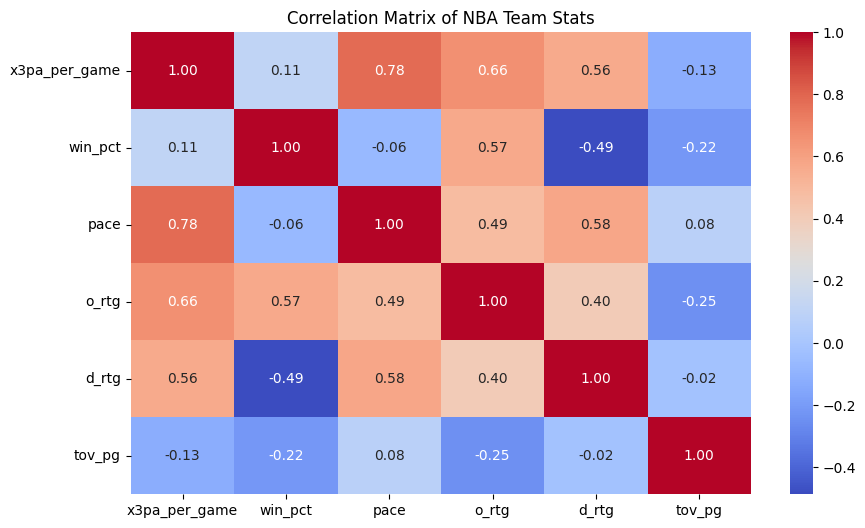

In [4]:
cols = [
    'x3pa_per_game',
    'win_pct',
    'pace',
    'o_rtg',
    'd_rtg',
    'tov_pg'
]

corr = main_table[cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of NBA Team Stats")
plt.show()

From this visual, we can understand that offensive and defensive ratings are the strongest predictors of an NBA team's success. While 3-point attempts and turnovers influence winning to a lesser extent, pace alone shows little correlation with win percentage, highlighting that efficiency significantly outweighs speed or volume.

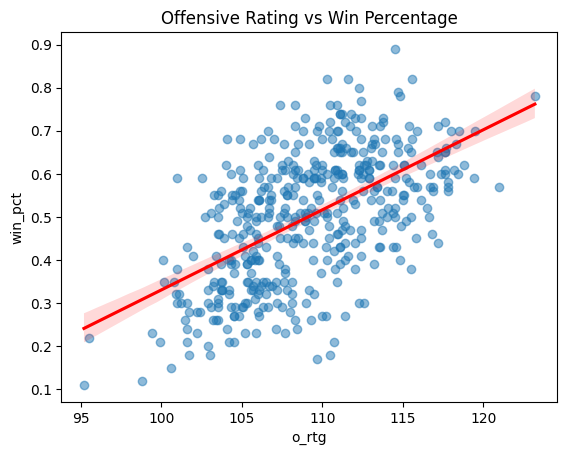

In [5]:
sns.regplot(
    data=main_table,
    x="o_rtg",
    y="win_pct",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Offensive Rating vs Win Percentage")
plt.show()


Teams with higher offensive ratings consistently achieve higher win percentages, confirming offensive efficiency as a key driver of success.

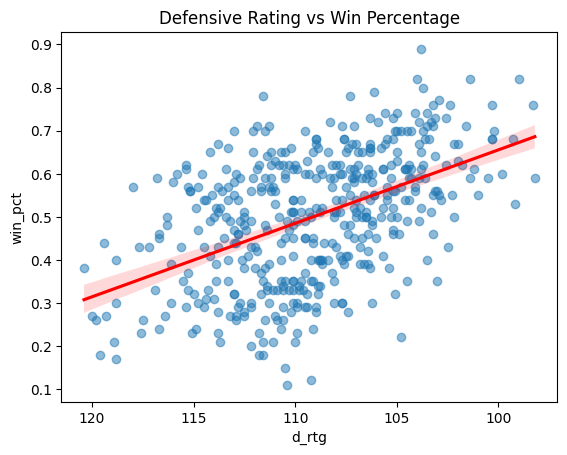

In [6]:
sns.regplot(
    data=main_table,
    x="d_rtg",
    y="win_pct",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Defensive Rating vs Win Percentage")
plt.gca().invert_xaxis()
plt.show()


Teams that allow fewer points per 100 possessions tend to win more games, highlighting the importance of defensive efficiency.

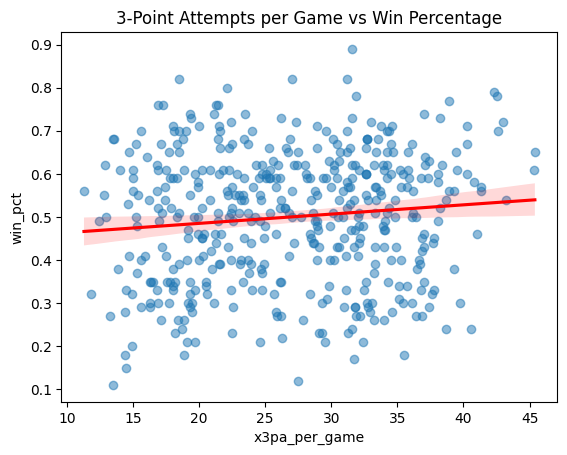

In [7]:
sns.regplot(
    data=main_table,
    x="x3pa_per_game",
    y="win_pct",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("3-Point Attempts per Game vs Win Percentage")
plt.show()


While 3-point attempts per game show a slight positive trend, volume alone does not strongly predict winning without efficiency.

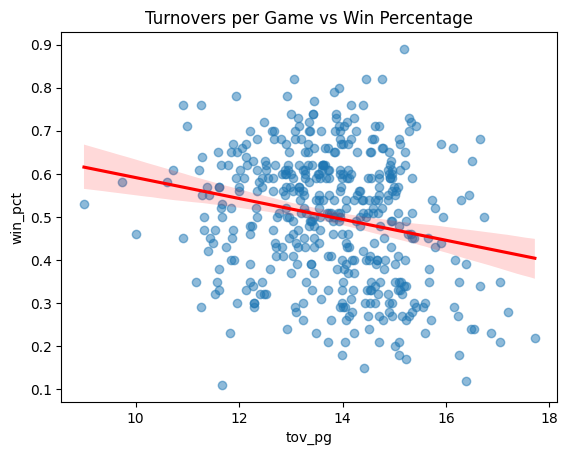

In [8]:
sns.regplot(
    data=main_table,
    x="tov_pg",
    y="win_pct",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Turnovers per Game vs Win Percentage")
plt.show()


Teams that commit fewer turnovers tend to win more, though the effect is weaker than offensive or defensive efficiency.

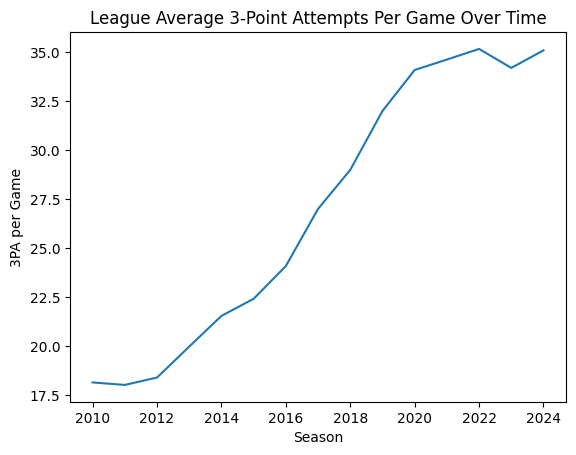

In [9]:
three_pa_trend = (
    main_table.groupby("season")["x3pa_per_game"]
    .mean()
    .reset_index()
)

plt.plot(three_pa_trend["season"], three_pa_trend["x3pa_per_game"])
plt.title("League Average 3-Point Attempts Per Game Over Time")
plt.xlabel("Season")
plt.ylabel("3PA per Game")
plt.show()


The NBA has seen a sharp increase in 3-point attempts over time, reflecting a league-wide shift toward perimeter-oriented offenses. The Golden State Warriors were the catalyst as they took the league by storm beginning in 2014 with the splash brothers, Klay Thompson and Stephen Curry, shooting at a high clip and a pace focused small-ball offense. This proved to be a winning formula which explains the league-wide wise in 3PA. 

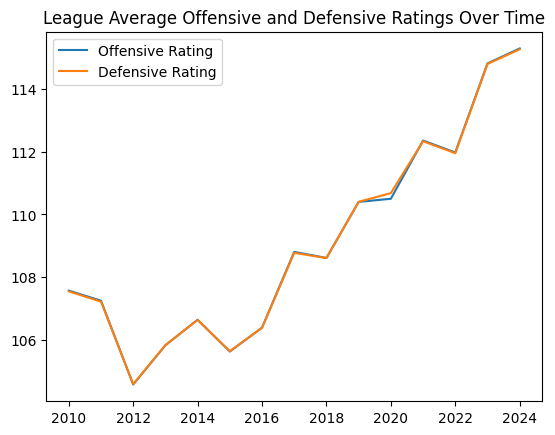

In [10]:
rating_trends = (
    main_table.groupby("season")[["o_rtg", "d_rtg"]]
    .mean()
    .reset_index()
)

plt.plot(rating_trends["season"], rating_trends["o_rtg"], label="Offensive Rating")
plt.plot(rating_trends["season"], rating_trends["d_rtg"], label="Defensive Rating")
plt.legend()
plt.title("League Average Offensive and Defensive Ratings Over Time")
plt.show()


Offensive efficiency has increased over time, while defensive ratings have also risen, suggesting rule changes and offensive innovation have favoured scoring. We this this today as average end scores have been on a rise as rule changes have increased pace and overall offensive strategy.

**Regression:** Which team statistics best predict NBA win percentage?

In [11]:
main_table

,season,team,x3pa_per_game,wins,loss,win_pct,pace,o_rtg,d_rtg,tov_pg
0,2010,Atlanta Hawks,17.7,53.0,29.0,0.65,90.1,111.9,106.7,11.95
1,2010,Boston Celtics,17.5,50.0,32.0,0.61,91.6,107.7,103.8,14.87
2,2010,Charlotte Bobcats,16.2,44.0,38.0,0.54,90.4,104.4,102.8,15.73
3,2010,Chicago Bulls,13.0,41.0,41.0,0.50,93.1,103.5,105.3,14.33
4,2010,Cleveland Cavaliers,19.3,61.0,21.0,0.74,91.4,111.2,104.1,13.87
...,...,...,...,...,...,...,...,...,...,...
460,2024,Sacramento Kings,39.3,46.0,36.0,0.56,98.8,116.9,115.2,13.15
461,2024,San Antonio Spurs,36.4,22.0,60.0,0.27,101.1,110.0,116.4,15.15
462,2024,Toronto Raptors,33.1,25.0,57.0,0.30,99.4,112.3,118.8,13.99
463,2024,Utah Jazz,36.5,31.0,51.0,0.38,99.5,115.5,120.4,15.67


R²: 0.924
RMSE: 0.041


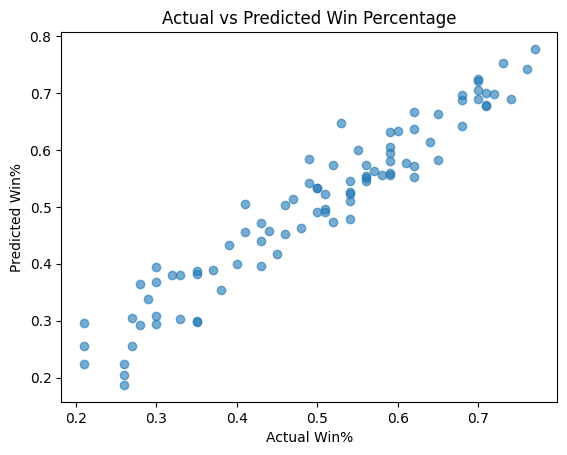

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = [
    "o_rtg",
    "d_rtg",
    "x3pa_per_game",
    "tov_pg",
    "pace"
]

X = main_table[features]
y = main_table["win_pct"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 3))
print("RMSE:", round(rmse, 3))

coef_df = pd.DataFrame({
    "feature": features,
    "coef": model.coef_
}).sort_values("coef", ascending=False)

coef_df

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Win%")
plt.ylabel("Predicted Win%")
plt.title("Actual vs Predicted Win Percentage")
plt.show()



In [21]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

X_sm = main_table[["o_rtg","d_rtg","x3pa_per_game","pace","tov_pg"]]
X_sm = sm.add_constant(X_sm)
y_sm = main_table["win_pct"]

sm_model = sm.OLS(y_sm, X_sm).fit()
print(sm_model.summary())


                            OLS Regression Results                            
Dep. Variable:                win_pct   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     1239.
Date:                Thu, 25 Dec 2025   Prob (F-statistic):          3.98e-258
Time:                        09:13:45   Log-Likelihood:                 823.03
No. Observations:                 450   AIC:                            -1634.
Df Residuals:                     444   BIC:                            -1609.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4829      0.095      5.065

To complement the predictive model, I estimated a classical OLS regression using statsmodels to examine coefficient significance and confirm the directionality of key predictors. We can immediately notice that offensive and defensive rating are significant at predicting win percentage.